# 🩺 Diabetes Risk Prediction & Patient Segmentation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score,
    classification_report, precision_score,
    recall_score, roc_curve, auc
)
from matplotlib.colors import ListedColormap
from joblib import dump, load

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
# Change Missing Values to NaN
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)

# Summary statistics
print("Summary Statistics:")
df.describe().T

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
# Check for missing values
(df == 0).sum()

,0
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Pregnancies,17
Glucose,135
BloodPressure,46
SkinThickness,50
Insulin,185
BMI,247
DiabetesPedigreeFunction,517
Age,52
Outcome,2


# Data Preprocessing

In [ ]:
# Impute missing values with median or mean based on skewness
for column in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    skewness = df[column].skew()
    if abs(skewness) < 0.5:
        df[column] = df[column].fillna(df[column].mean())
    else:
        df[column] = df[column].fillna(df[column].median())

In [ ]:
df2 = df[(df['Insulin'] == 0) & (df['Outcome'] == 0)]
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [ ]:
df = df[~df.index.isin(df2.index)]
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [ ]:
mean_bmi = df.loc[df['BMI'] != 0, 'BMI'].mean()
mean_bmi

np.float64(32.45520833333333)

In [ ]:
df.loc[371, 'BMI'] = mean_bmi
df[df['BMI'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


# Visualization of Features

No Diabetes (0): 500 (65.1%)
Diabetes    (1): 268 (34.9%)


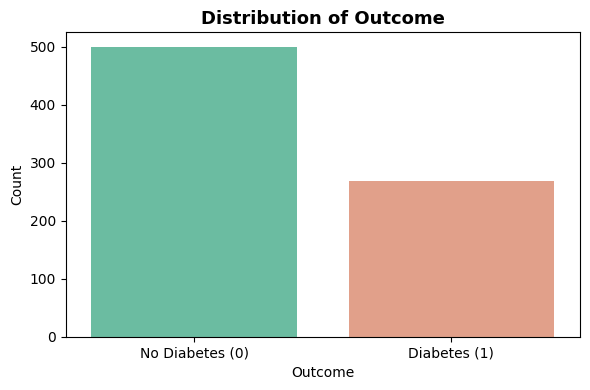

In [ ]:
# Class Balance
plt.figure(figsize=(6, 4))

df_plot = df.copy()
df_plot['Outcome'] = df_plot['Outcome'].map({0: 'No Diabetes (0)', 1: 'Diabetes (1)'})
sns.countplot(x='Outcome', data=df_plot,
              palette={'No Diabetes (0)': '#5DCAA5', 'Diabetes (1)': '#F0997B'},
              order=['No Diabetes (0)', 'Diabetes (1)'])
plt.title('Distribution of Outcome', fontsize=13, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Count')
counts = df['Outcome'].value_counts()
print(f'No Diabetes (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Diabetes    (1): {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
plt.tight_layout()
plt.show()

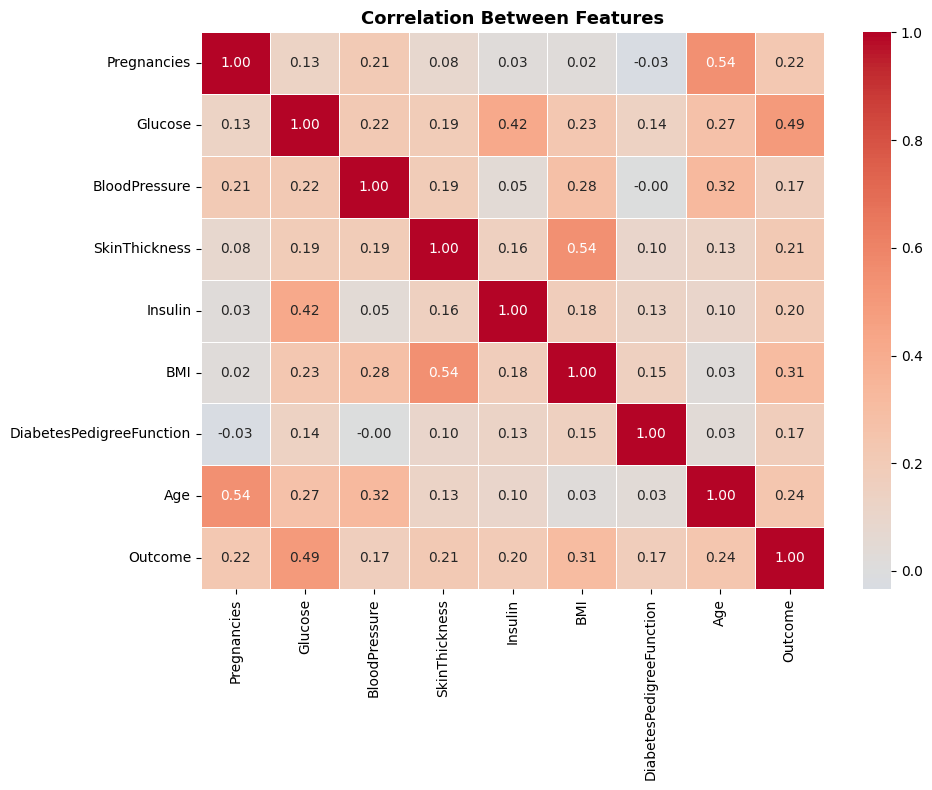

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_data = df.corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Correlation Between Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

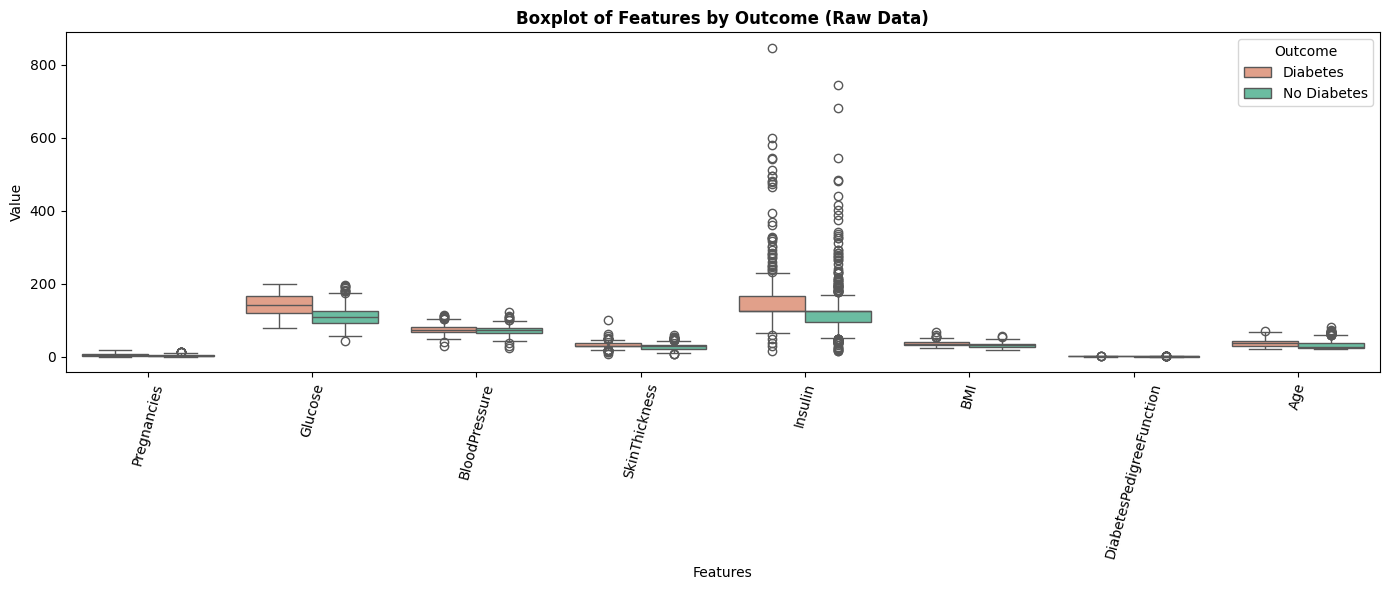

In [ ]:
# Boxplot — all features by Outcome
data_melted = pd.melt(df, id_vars='Outcome', var_name='Features', value_name='Value')

data_melted['Outcome'] = data_melted['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})
plt.figure(figsize=(14, 6))
sns.boxplot(x='Features', y='Value', hue='Outcome', data=data_melted,
            palette={'No Diabetes': '#5DCAA5', 'Diabetes': '#F0997B'},
            order=[c for c in df.columns if c != 'Outcome'])
plt.xticks(rotation=75)
plt.title('Boxplot of Features by Outcome (Raw Data)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def remove_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

In [ ]:
columns_to_normalize = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

In [ ]:
log_array = np.log1p(df[columns_to_normalize])

In [ ]:
log_df = pd.DataFrame(log_array, columns=columns_to_normalize)

In [ ]:
log_df['Outcome'] = df['Outcome'].values

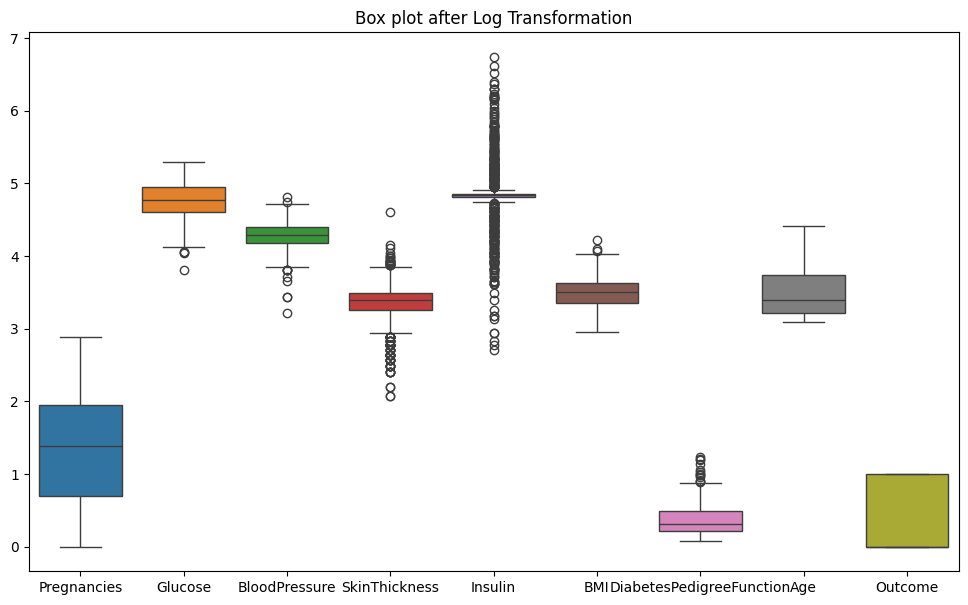

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(log_df)
plt.title("Box plot after Log Transformation")
plt.show()

# Drop Outliers

In [ ]:
log_df = remove_outliers(log_df)
log_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.945910,5.003946,4.290459,3.583519,4.836282,3.543854,0.486738,3.931826,1
1,0.693147,4.454347,4.204693,3.401197,4.836282,3.317816,0.300845,3.465736,0
2,2.197225,5.214936,4.174387,3.401197,4.836282,3.190476,0.514021,3.496508,1
5,1.791759,4.762174,4.317488,3.401197,4.836282,3.280911,0.183155,3.433987,0
7,2.397895,4.753590,4.295995,3.401197,4.836282,3.591818,0.125751,3.401197,0
...,...,...,...,...,...,...,...,...,...
761,2.302585,5.141664,4.317488,3.465736,4.836282,3.806662,0.338613,3.784190,1
762,2.302585,4.499810,4.143135,3.401197,4.836282,3.157000,0.132781,3.526361,0
764,1.098612,4.812184,4.262680,3.332205,4.836282,3.632309,0.292670,3.332205,0
766,0.693147,4.844187,4.110874,3.401197,4.836282,3.437208,0.299364,3.871201,1


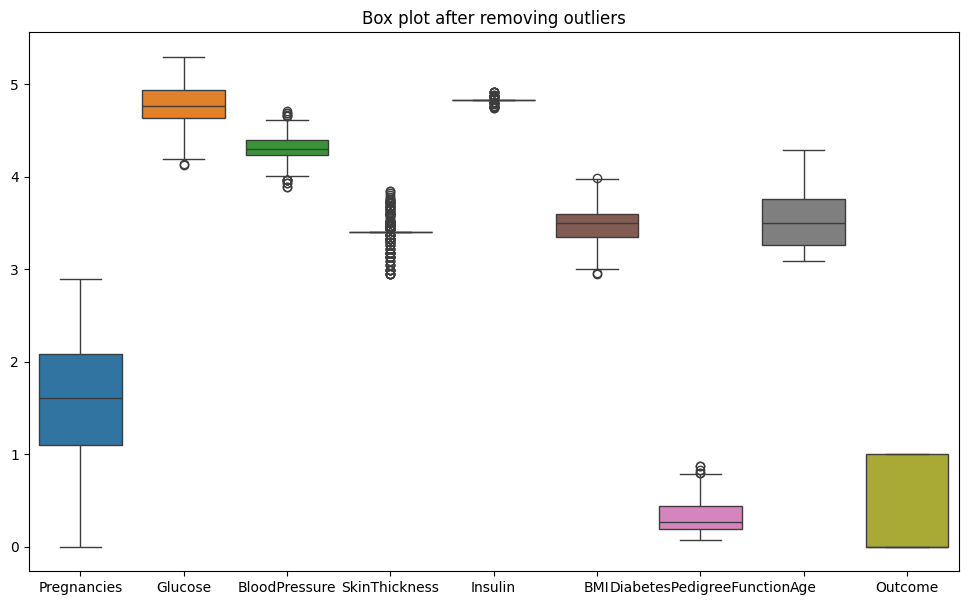

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(log_df)
plt.title("Box plot after removing outliers")
plt.show()

In [ ]:
print(f"Number of rows to remove outliers: {df.shape[0]}")
print(f"Number of rows after removing outliers: {log_df.shape[0]}")

Number of rows to remove outliers: 768
Number of rows after removing outliers: 387


# Analysis of Diabetic Cases

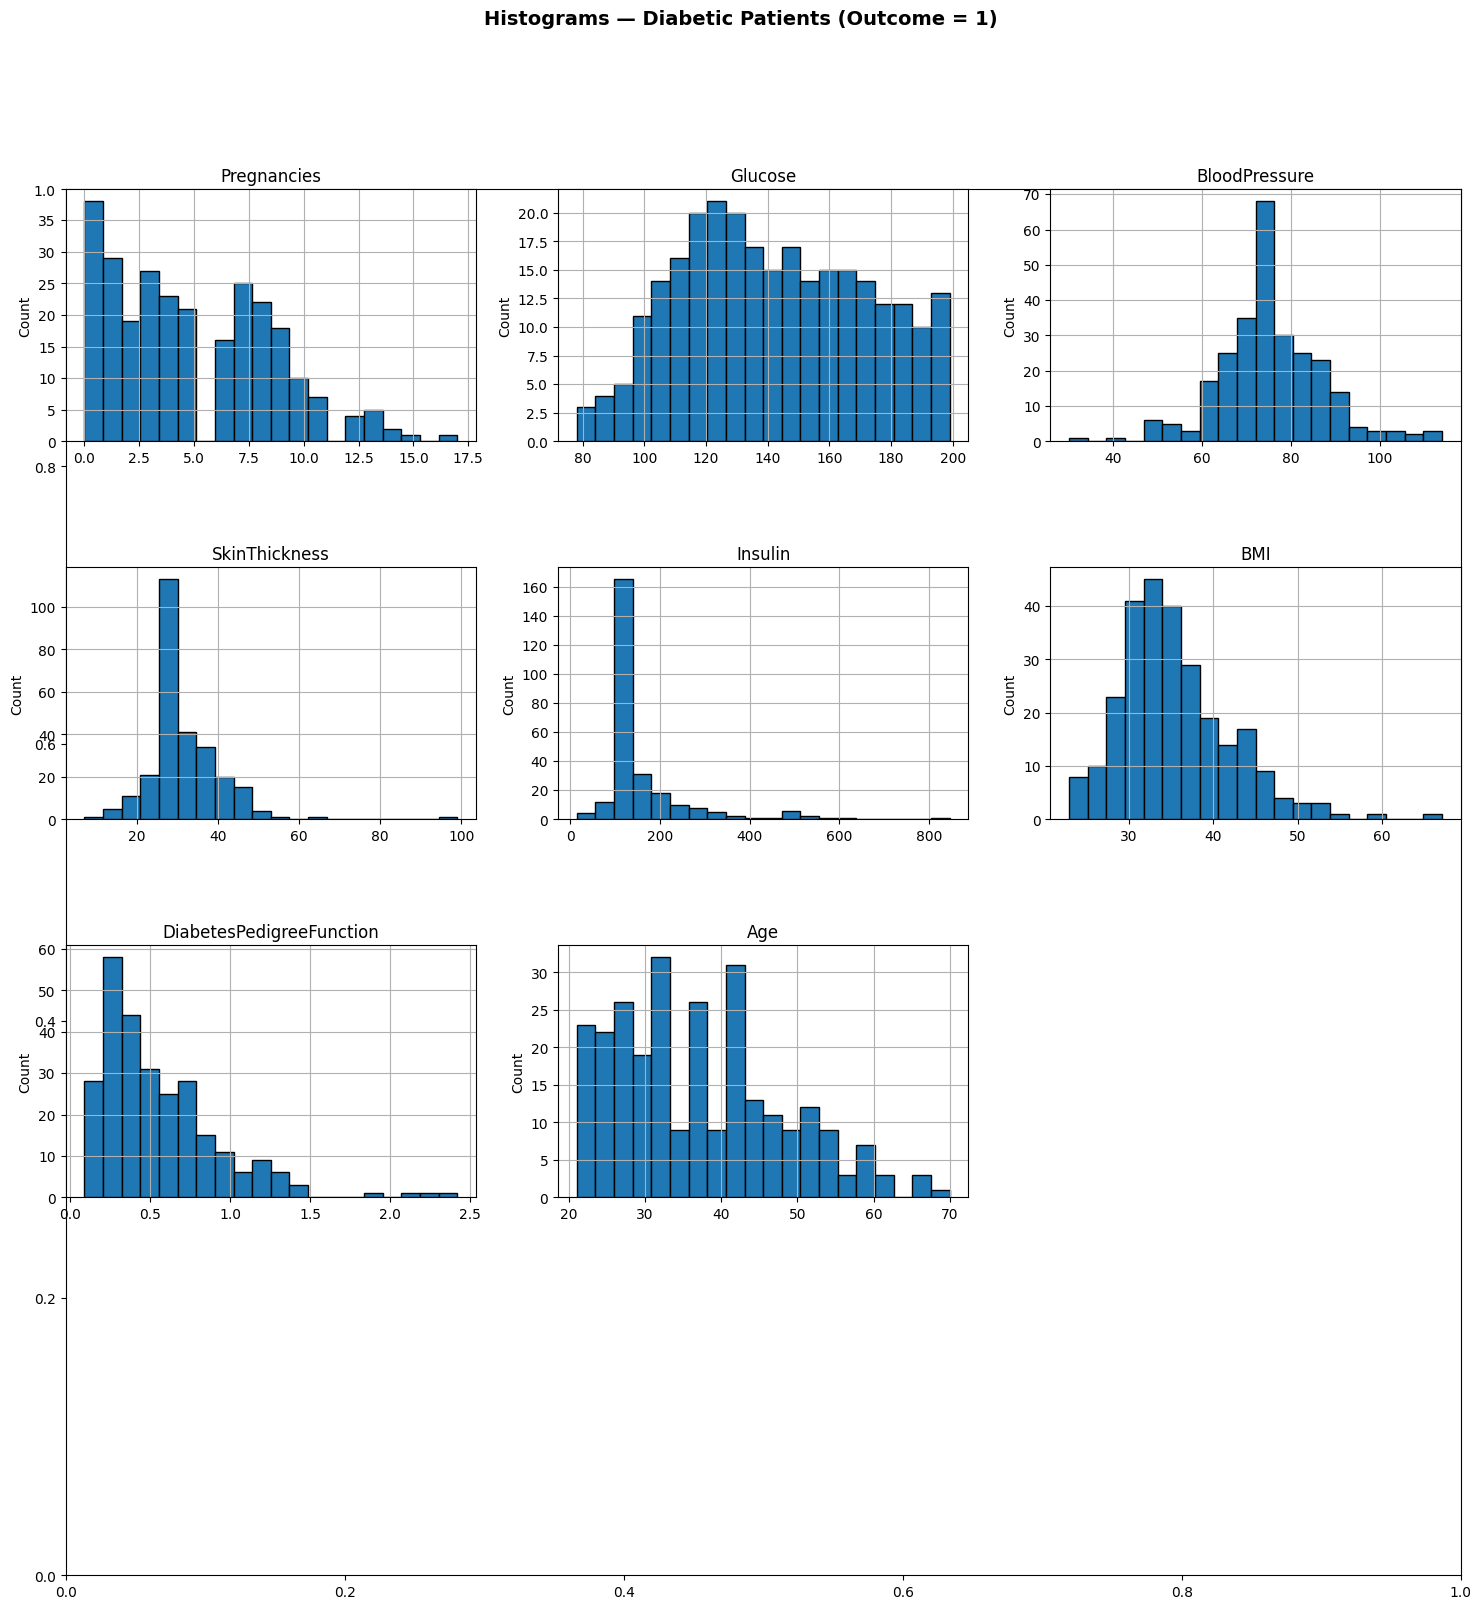

In [ ]:
#General Analysis

data1 = df[df["Outcome"]==1]
columns = df.columns[:8]
plt.subplots(figsize=(18,18))
length =len(columns)
for i,j in itertools.zip_longest(columns,range(length)):
    plt.subplot(int(length/2), 3, j+1)
    plt.subplots_adjust(wspace=0.2,hspace=0.5)
    plt.ylabel("Count")
    data1[i].hist(bins=20,edgecolor='black')
    plt.title(i)
plt.suptitle('Histograms — Diabetic Patients (Outcome = 1)', fontsize=14, fontweight='bold')
plt.show()

# Analysis of Non-Diabetic Cases

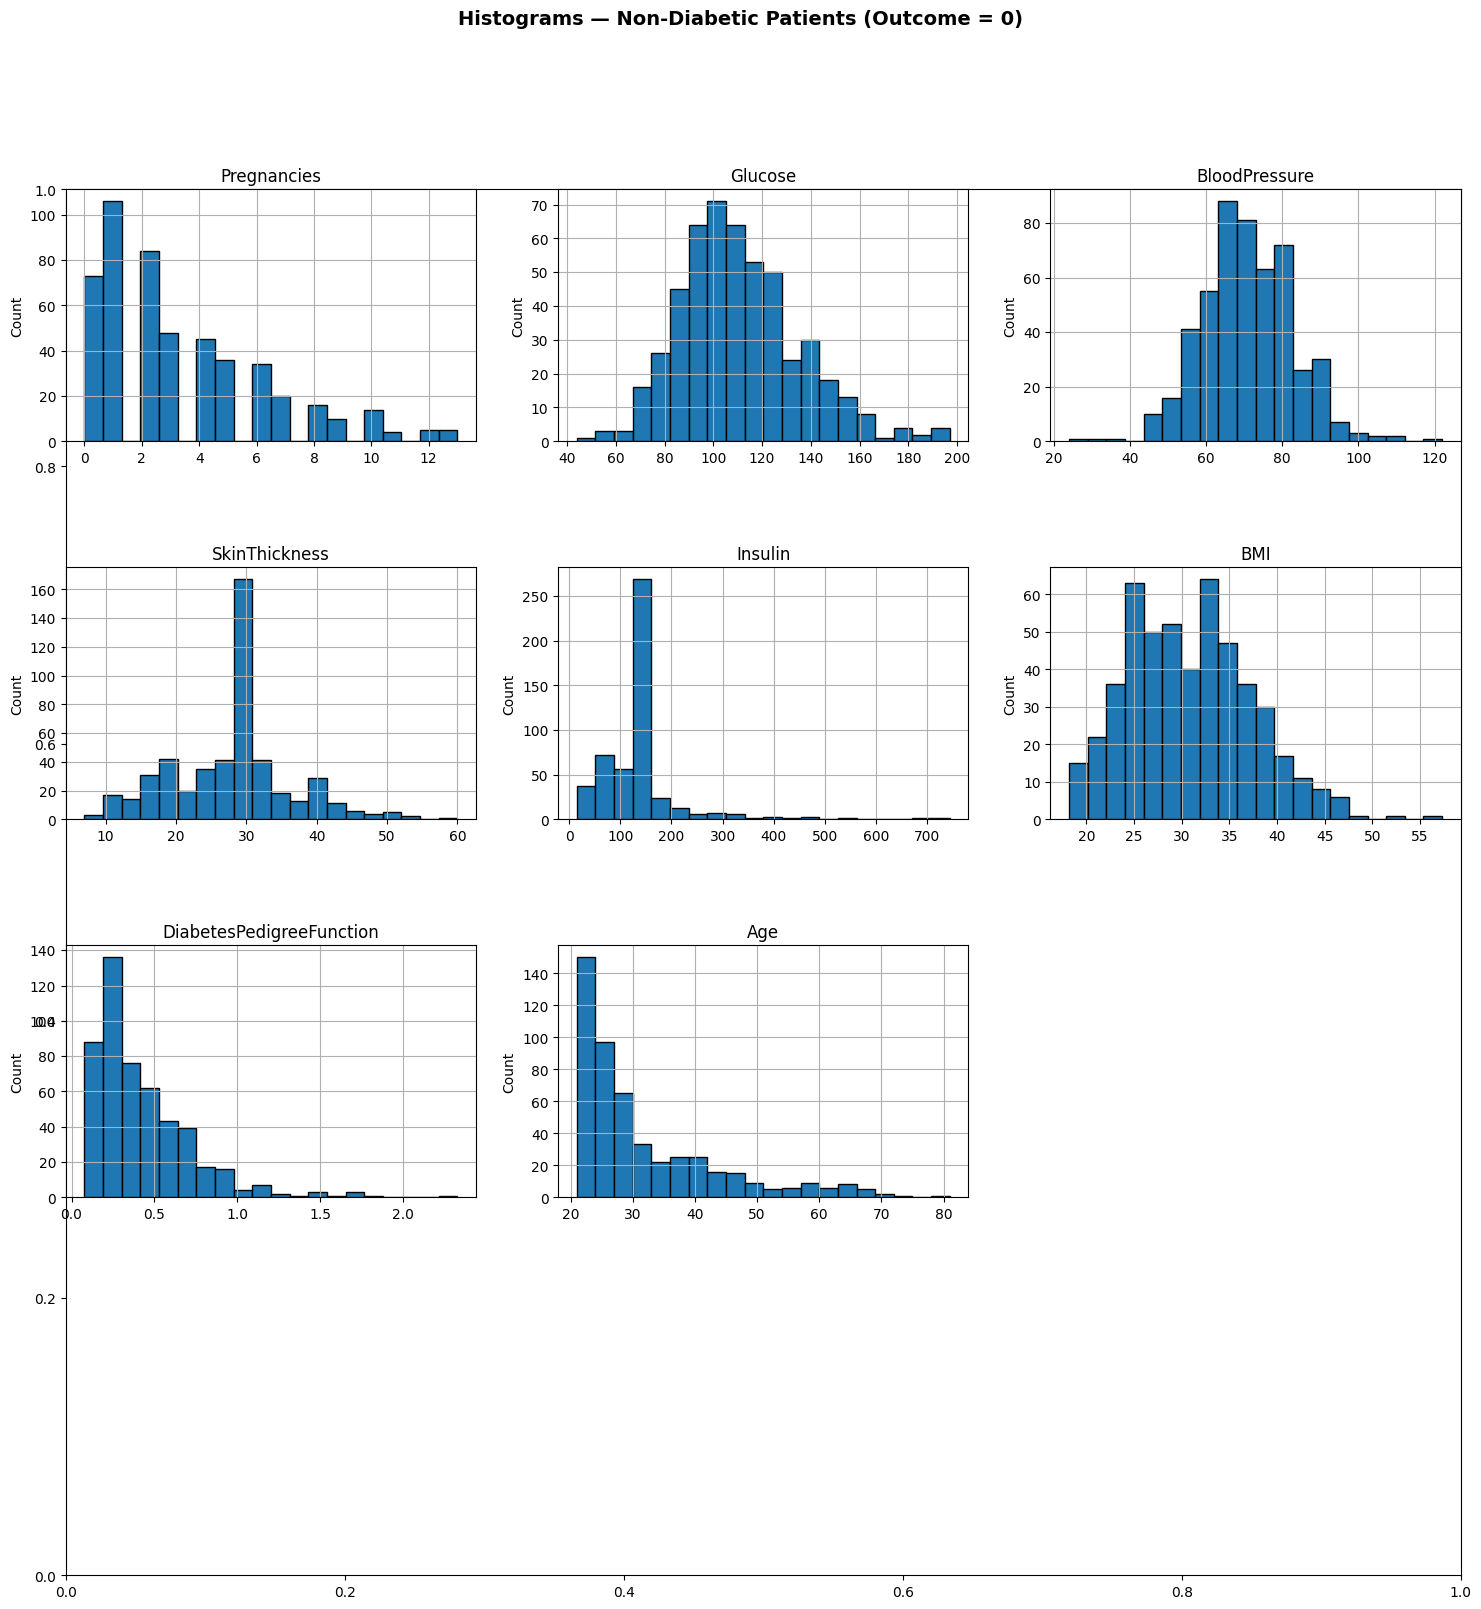

In [ ]:
#General Analysis

data1 = df[df["Outcome"]==0]
columns = df.columns[:8]
plt.subplots(figsize=(18,18))
length =len(columns)
for i,j in itertools.zip_longest(columns,range(length)):
    plt.subplot(int(length/2), 3, j+1)
    plt.subplots_adjust(wspace=0.2,hspace=0.5)
    plt.ylabel("Count")
    data1[i].hist(bins=20,edgecolor='black')
    plt.title(i)
plt.suptitle('Histograms — Non-Diabetic Patients (Outcome = 0)', fontsize=14, fontweight='bold')
plt.show()

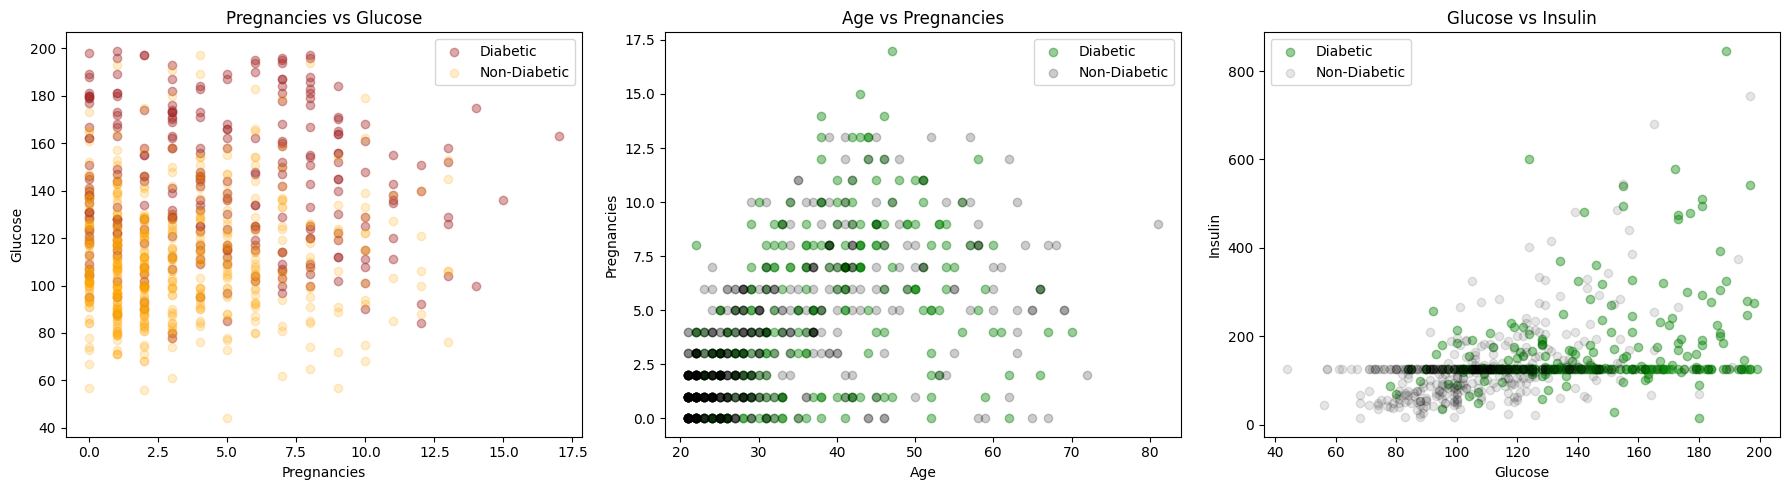

In [ ]:
# Scatter plots — feature relationships
p = df[df.Outcome == 1]   # Diabetic
n = df[df.Outcome == 0]   # Non-Diabetic

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(p.Pregnancies, p.Glucose, color='brown',  label='Diabetic',     alpha=0.4)
axes[0].scatter(n.Pregnancies, n.Glucose, color='orange', label='Non-Diabetic', alpha=0.2)
axes[0].set_xlabel('Pregnancies'); axes[0].set_ylabel('Glucose')
axes[0].set_title('Pregnancies vs Glucose'); axes[0].legend()

axes[1].scatter(p.Age, p.Pregnancies, color='green', label='Diabetic',     alpha=0.4)
axes[1].scatter(n.Age, n.Pregnancies, color='black', label='Non-Diabetic', alpha=0.2)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Pregnancies')
axes[1].set_title('Age vs Pregnancies'); axes[1].legend()

axes[2].scatter(p.Glucose, p.Insulin, color='green', label='Diabetic',     alpha=0.4)
axes[2].scatter(n.Glucose, n.Insulin, color='black', label='Non-Diabetic', alpha=0.1)
axes[2].set_xlabel('Glucose'); axes[2].set_ylabel('Insulin')
axes[2].set_title('Glucose vs Insulin'); axes[2].legend()

plt.tight_layout()
plt.show()

# Outlier Detection


In [ ]:
x = df.drop(['Outcome'], axis=1)
y = df['Outcome']

In [ ]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47


# Train Tespt Split & Standardization Processing

In [ ]:
from imblearn.combine import SMOTEENN
from collections import Counter

smote_enn = SMOTEENN(random_state=1)

X_resampled, y_resampled = smote_enn.fit_resample(x, y)
print("Before data augmentation:", Counter(y))
print("After data augemnation:", Counter(y_resampled))

Before data augmentation: Counter({0: 500, 1: 268})
After data augemnation: Counter({1: 288, 0: 248})


In [ ]:
test_size = 0.2
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=test_size, random_state=42, stratify=y)

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)   # fit on train only
x_test_sc  = scaler.transform(x_test)        # apply same scaler to test

print(f'Train size : {x_train_sc.shape[0]}')
print(f'Test  size : {x_test_sc.shape[0]}')

print("Data split complete!")
print(f"Training set: {x_train.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")
print(f"\nTraining set = {x_train.shape[0]/len(x)*100:.0f}% of data")
print(f"Test set = {x_test.shape[0]/len(x)*100:.0f}% of data")

# Inspect scaled training data
columns_list = x.columns # Define columns_list from the original feature DataFrame
x_train_df = pd.DataFrame(x_train_sc, columns=columns_list)
x_train_df['target'] = y_train
x_train_df.describe().round(3)

Train size : 614
Test  size : 154
Data split complete!
Training set: 614 samples
Test set: 154 samples

Training set = 80% of data
Test set = 20% of data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,target
count,614.000,614.000,614.000,614.000,614.000,614.000,614.000,614.000,490.000
mean,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.343
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,0.475
min,-1.153,-2.191,-3.926,-2.481,-1.559,-2.089,-1.192,-1.046,0.000
25%,-0.851,-0.756,-0.665,-0.455,-0.225,-0.707,-0.704,-0.792,0.000
50%,-0.247,-0.156,-0.013,-0.005,-0.161,-0.014,-0.288,-0.369,0.000
75%,0.659,0.611,0.640,0.333,-0.098,0.594,0.490,0.646,1.000
max,3.980,2.579,4.064,7.874,7.704,5.082,5.610,4.029,1.000


# Machine Learning Models

##Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split
x_train, x_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=1,
    stratify=y_resampled
)

# Scale
scaler = StandardScaler()

x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

# Train
LR = LogisticRegression(random_state=42, max_iter=1000)

LR.fit(x_train_sc, y_train)

# Predict
y_pred = LR.predict(x_test_sc)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print(classification_report(y_test, y_pred))

Accuracy: 0.8796296296296297
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        50
           1       0.88      0.90      0.89        58

    accuracy                           0.88       108
   macro avg       0.88      0.88      0.88       108
weighted avg       0.88      0.88      0.88       108



In [ ]:
# logistic Regretion Accurncy

# Re-apply StandardScaler to the current x_train and x_test from resampled data
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

LR = LogisticRegression(random_state=42, max_iter=1000)
LR.fit(x_train_sc, y_train)
LRscore = LR.score(x_test_sc, y_test)
print(f'Test Accuracy   : {LRscore:.4f}')

Test Accuracy   : 0.8796


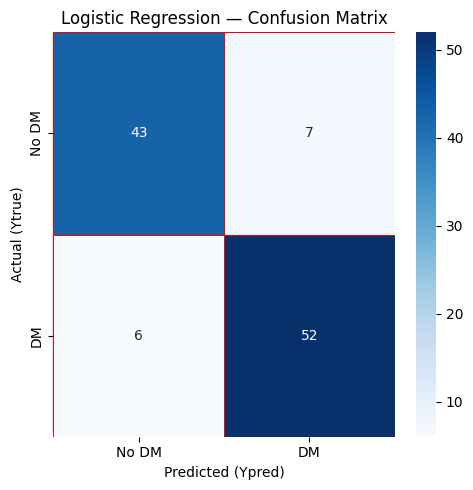

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure ypred_LR is defined
# Using y_pred from the 'reg' model which was trained on resampled data
ypred_LR = y_pred

# Confusion Matrix — Logistic Regression
CM_LR = confusion_matrix(y_test, ypred_LR)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(CM_LR, annot=True, linewidths=0.5, linecolor='red',
            fmt='.0f', ax=ax, cmap='Blues',
            xticklabels=['No DM', 'DM'], yticklabels=['No DM', 'DM'])
plt.xlabel('Predicted (Ypred)')
plt.ylabel('Actual (Ytrue)')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

PCA — DIMENSIONALITY REDUCTION (2 Components)
PC1 variance explained : 28.53%
PC2 variance explained : 18.70%
Total (2 PCs)          : 47.23%


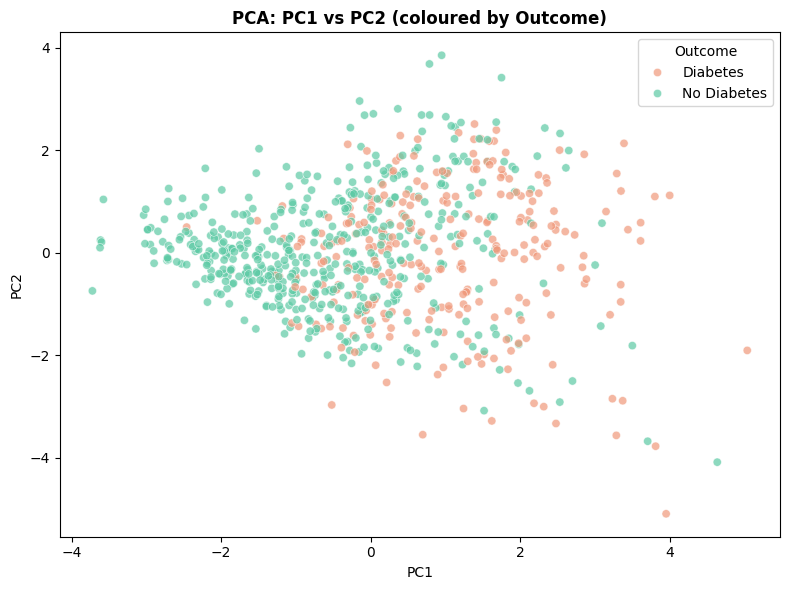

In [ ]:
print('=' * 50)
print('PCA — DIMENSIONALITY REDUCTION (2 Components)')
print('=' * 50)

scaler_pca   = StandardScaler()
x_scaled_pca = scaler_pca.fit_transform(x)

pca = PCA(n_components=2)
x_reduce_pca = pca.fit_transform(x_scaled_pca)

print(f'PC1 variance explained : {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2 variance explained : {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total (2 PCs)          : {sum(pca.explained_variance_ratio_)*100:.2f}%')

pca_data = pd.DataFrame(x_reduce_pca, columns=['PC1', 'PC2'])
pca_data['target'] = y
# Fix: map int to string labels for seaborn hue
pca_data['Outcome'] = pca_data['target'].map({0: 'No Diabetes', 1: 'Diabetes'})

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Outcome', data=pca_data,
                palette={'No Diabetes': '#5DCAA5', 'Diabetes': '#F0997B'}, alpha=0.7)
plt.title('PCA: PC1 vs PC2 (coloured by Outcome)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Support Vector Machine (SVM)

In [ ]:
# scalar
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

print('=' * 50)
print('SUPPORT VECTOR MACHINE (SVM)')
print('=' * 50)

# probability=True required for predict_proba (ROC curve)
SVM = SVC(random_state=42, probability=True)

svm_cv = cross_val_score(SVM, x_train_sc, y_train, cv=5)
print(f'CV Avg Accuracy : {np.mean(svm_cv):.4f} ± {np.std(svm_cv):.4f}')

SVM.fit(x_train_sc, y_train)
SVMscore = SVM.score(x_test_sc, y_test)
print(f'Test Accuracy   : {SVMscore:.4f}')

ypred_SVM = SVM.predict(x_test_sc)

SUPPORT VECTOR MACHINE (SVM)
CV Avg Accuracy : 0.9463 ± 0.0174
Test Accuracy   : 0.9444


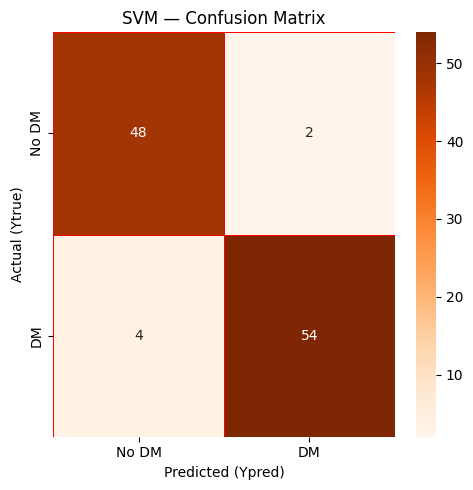

In [ ]:
# Confusion Matrix — SVM
CM_SVM = confusion_matrix(y_test, ypred_SVM)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(CM_SVM, annot=True, linewidths=0.5, linecolor='red',
            fmt='.0f', ax=ax, cmap='Oranges',
            xticklabels=['No DM', 'DM'], yticklabels=['No DM', 'DM'])
plt.xlabel('Predicted (Ypred)')
plt.ylabel('Actual (Ytrue)')
plt.title('SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

# Decision Tree

In [ ]:
#Decision Tree Algorithm

from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier()

In [ ]:
print('=' * 50)
print('DECISION TREE')
print('=' * 50)

DTC = DecisionTreeClassifier(max_depth=5, random_state=42)

# Fixed: cv=55 was invalid → changed to cv=10
dt_cv = cross_val_score(DTC, x_train_sc, y_train, cv=10)
print(f'CV Avg Accuracy : {np.mean(dt_cv):.4f} ± {np.std(dt_cv):.4f}')

DTC.fit(x_train_sc, y_train)
DTCscore = DTC.score(x_test_sc, y_test)
print(f'Test Accuracy   : {DTCscore:.4f}')

ypred_DTC = DTC.predict(x_test_sc)

DECISION TREE
CV Avg Accuracy : 0.9159 ± 0.0331
Test Accuracy   : 0.9352


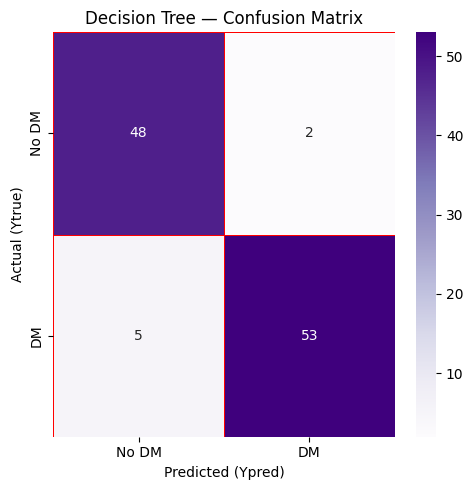

In [ ]:
# Confusion Matrix — Decision Tree
CM_DTC = confusion_matrix(y_test, ypred_DTC)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(CM_DTC, annot=True, linewidths=0.5, linecolor='red',
            fmt='.0f', ax=ax, cmap='Purples',
            xticklabels=['No DM', 'DM'], yticklabels=['No DM', 'DM'])
plt.xlabel('Predicted (Ypred)')
plt.ylabel('Actual (Ytrue)')
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

# Random Forest

In [ ]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

Best n_estimators: 80


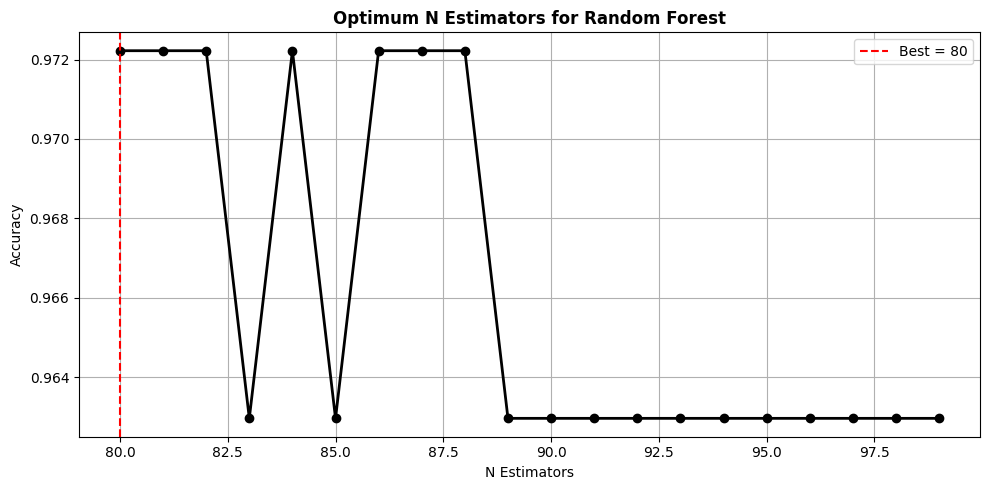

In [ ]:
# Find optimal n_estimators
scores_rf = []
for each in range(80, 100):
    rf_tmp = RandomForestClassifier(n_estimators=each, random_state=42)
    rf_tmp.fit(x_train_sc, y_train)
    scores_rf.append(rf_tmp.score(x_test_sc, y_test))

best_n = range(80, 100)[np.argmax(scores_rf)]
print(f'Best n_estimators: {best_n}')

plt.figure(figsize=(10, 5))
plt.plot(range(80, 100), scores_rf, color='black', linewidth=2, marker='o')
plt.axvline(best_n, color='red', linestyle='--', label=f'Best = {best_n}')
plt.title('Optimum N Estimators for Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('N Estimators'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [ ]:
print('=' * 50)
print('RANDOM FOREST')
print('=' * 50)

RFC = RandomForestClassifier(n_estimators=82, random_state=42)

rfc_cv = cross_val_score(RFC, x_train_sc, y_train, cv=10)
print(f'CV Avg Accuracy : {np.mean(rfc_cv):.4f} ± {np.std(rfc_cv):.4f}')

RFC.fit(x_train_sc, y_train)
RFCscore = RFC.score(x_test_sc, y_test)
print(f'Test Accuracy   : {RFCscore:.4f}')

ypred_RFC = RFC.predict(x_test_sc)

RANDOM FOREST
CV Avg Accuracy : 0.9511 ± 0.0218
Test Accuracy   : 0.9722


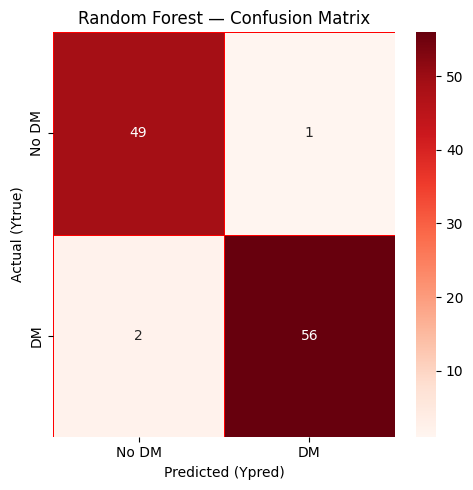

In [ ]:
# Confusion Matrix — Random Forest
CM_RFC = confusion_matrix(y_test, ypred_RFC)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(CM_RFC, annot=True, linewidths=0.5, linecolor='red',
            fmt='.0f', ax=ax, cmap='Reds',
            xticklabels=['No DM', 'DM'], yticklabels=['No DM', 'DM'])
plt.xlabel('Predicted (Ypred)')
plt.ylabel('Actual (Ytrue)')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
x_test.shape

(108, 8)

In [ ]:
# Training Accuracy
train_acc = RFC.score(x_train_sc, y_train)

# Testing Accuracy
test_acc = RFC.score(x_test_sc, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc*100)

Training Accuracy: 1.0
Testing Accuracy: 97.22222222222221


In [ ]:
train_loss = 1 - train_acc
test_loss = 1 - test_acc

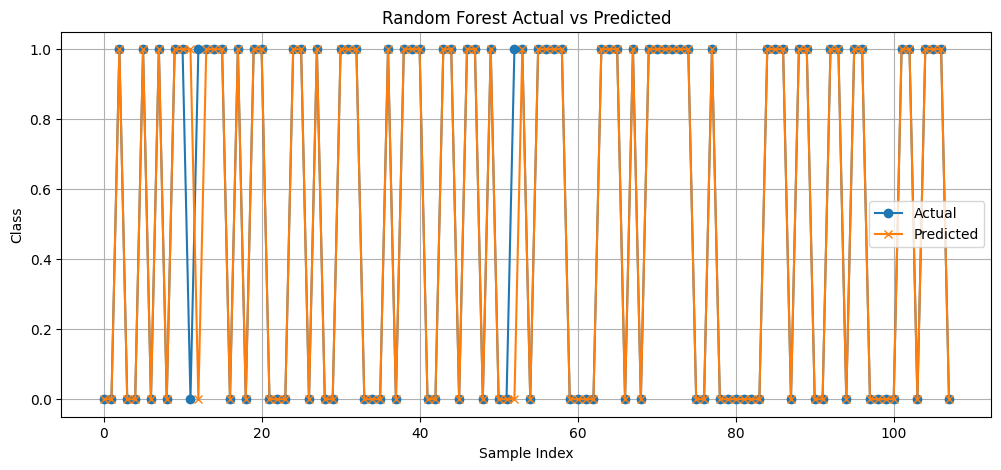

In [ ]:
import matplotlib.pyplot as plt

# Predict values
y_pred = RFC.predict(x_test_sc)

# Plot Actual vs Predicted
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')

plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.title("Random Forest Actual vs Predicted")

plt.legend()
plt.grid(True)

plt.show()

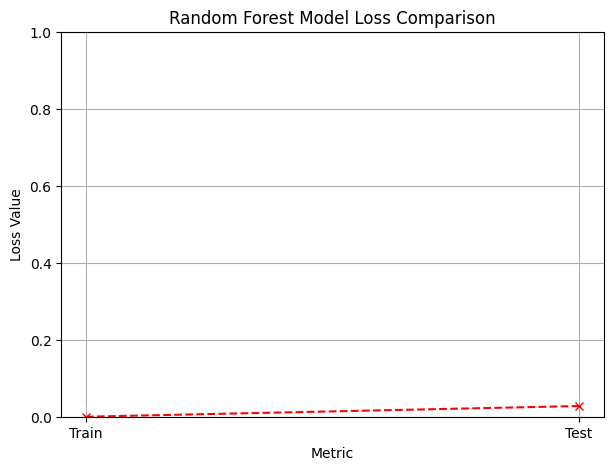

In [ ]:
import matplotlib.pyplot as plt

labels = ['Train', 'Test'] # Define labels for the plot

# The loss plots were commented out, if you'd like to visualize them, let me know!
plt.figure(figsize=(7, 5))
plt.plot(labels, [train_loss, test_loss], marker='x', linestyle='--', color='red')
plt.title('Random Forest Model Loss Comparison')
plt.xlabel('Metric')
plt.ylabel('Loss Value')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

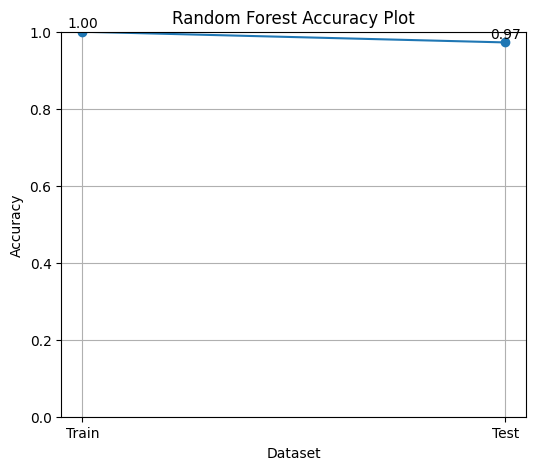

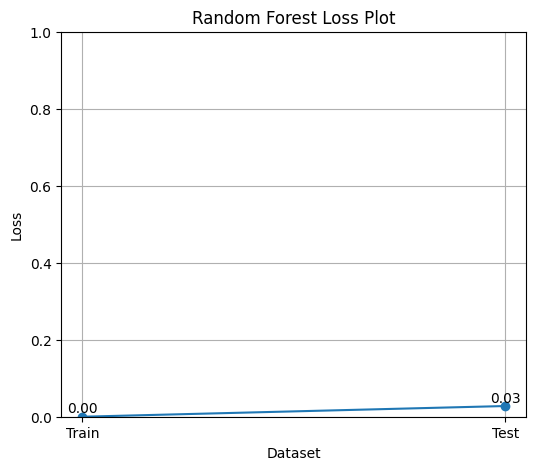

In [ ]:
import matplotlib.pyplot as plt

# Training Accuracy
train_acc = RFC.score(x_train_sc, y_train)

# Testing Accuracy
test_acc = RFC.score(x_test_sc, y_test)

# Loss Calculation
train_loss = 1 - train_acc
test_loss = 1 - test_acc

# Labels
labels = ['Train', 'Test']

# ---------------- Accuracy Line Plot ----------------
accuracy_values = [train_acc, test_acc]

plt.figure(figsize=(6,5))

plt.plot(labels, accuracy_values, marker='o')

plt.ylim(0, 1)
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy Plot")
plt.grid(True)

for i, v in enumerate(accuracy_values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

# ---------------- Loss Line Plot ----------------
loss_values = [train_loss, test_loss]

plt.figure(figsize=(6,5))

plt.plot(labels, loss_values, marker='o')

plt.ylim(0, 1)
plt.xlabel("Dataset")
plt.ylabel("Loss")
plt.title("Random Forest Loss Plot")
plt.grid(True)

for i, v in enumerate(loss_values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

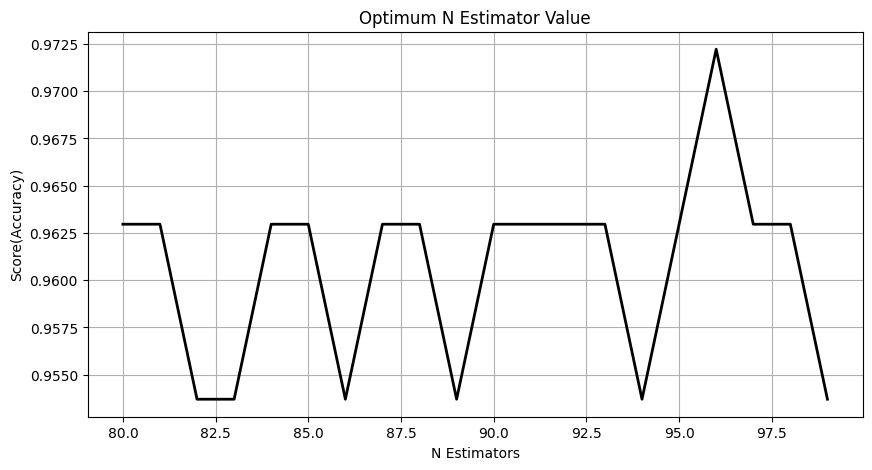

In [ ]:
#Find Optimum K value
scores = []
for each in range(80,100):
    RFfind = RandomForestClassifier(n_estimators = each)
    RFfind.fit(x_train_sc,y_train)
    scores.append(RFfind.score(x_test_sc,y_test))

plt.figure(1, figsize=(10, 5))
plt.plot(range(80,100),scores,color="black",linewidth=2)
plt.title("Optimum N Estimator Value")
plt.xlabel("N Estimators")
plt.ylabel("Score(Accuracy)")
plt.grid(True)
plt.show()

In [ ]:
RFC = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

In [ ]:
RFC.fit(x_train_sc,y_train)
print("Accuracy:", RFC.score(x_test_sc, y_test))

Accuracy: 0.9629629629629629


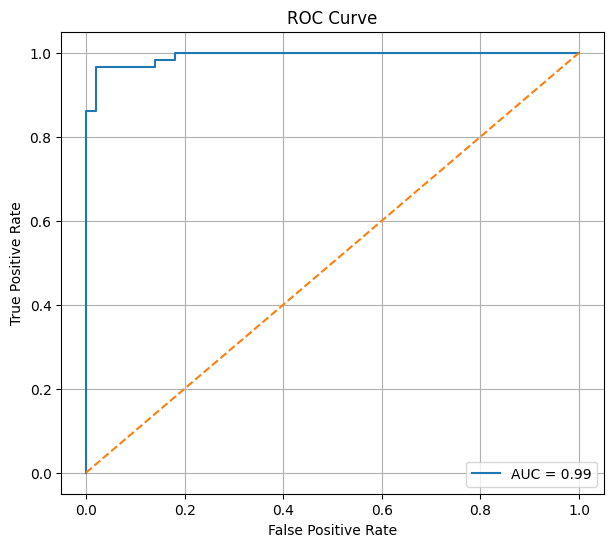

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = RFC.predict_proba(x_test_sc)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

# Evaluation of Results

In [ ]:
#F1-Score For Logistic Regression
from sklearn.metrics import f1_score
LRf1 = f1_score(y_test, ypred_LR, average='weighted')
LRf1

0.879536101758324

In [ ]:
#SVM
SVMf1 = f1_score(y_test, ypred_SVM, average='weighted')
SVMf1

0.9445017773191148

In [ ]:
#Decision Tree
DTf1=f1_score(y_test, ypred_DTC, average='weighted')
DTf1

0.9352687166073196

In [ ]:
#RandomForest
RFf1=f1_score(y_test, ypred_RFC, average='weighted')
RFf1

0.9722389630267374

# Result Visualization

In [ ]:
import plotly.graph_objs as go
from plotly.offline import iplot

scores = [LRscore, SVMscore, DTCscore, RFCscore]

AlgorithmsName = [
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "Random Forest"
]

# Create plot trace
trace1 = go.Scatter(
    x=AlgorithmsName,
    y=scores,
    name='Algorithm Names',
    marker=dict(
        color='rgba(0,255,0,0.5)',
        line=dict(color='rgb(0,0,0)', width=2)
    ),
    text=AlgorithmsName
)

data = [trace1]

# Define layout
layout = go.Layout(
    barmode="group",
    xaxis=dict(title='ML Algorithms', ticklen=5, zeroline=False),
    yaxis=dict(title='Prediction Scores', ticklen=5, zeroline=False)
)

fig = go.Figure(data=data, layout=layout)

iplot(fig)

# Scatter Plot For Comparasion of ML Algorithms Prediciton Scores (F1)

In [ ]:
scores_f1 = [LRf1, SVMf1, DTf1, RFf1]

# Make sure the number of names matches the number of scores
AlgorithmsName = [
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "Random Forest"
]

# Create trace
trace1 = go.Scatter(
    x=AlgorithmsName,
    y=scores_f1,
    name='Algorithm Names',
    mode='markers+lines',  # Better visualization for comparison
    marker=dict(
        color='rgba(225,126,0,0.5)',
        line=dict(color='rgb(0,0,0)', width=2)
    ),
    text=AlgorithmsName
)

data = [trace1]

# Layout
layout = go.Layout(
    title="Scatter Plot for Comparison of ML Algorithms' F1 Scores",
    xaxis=dict(title='ML Algorithms', ticklen=5, zeroline=False),
    yaxis=dict(title='F1 Score', ticklen=5, zeroline=False)
)

fig = go.Figure(data=data, layout=layout)

iplot(fig)

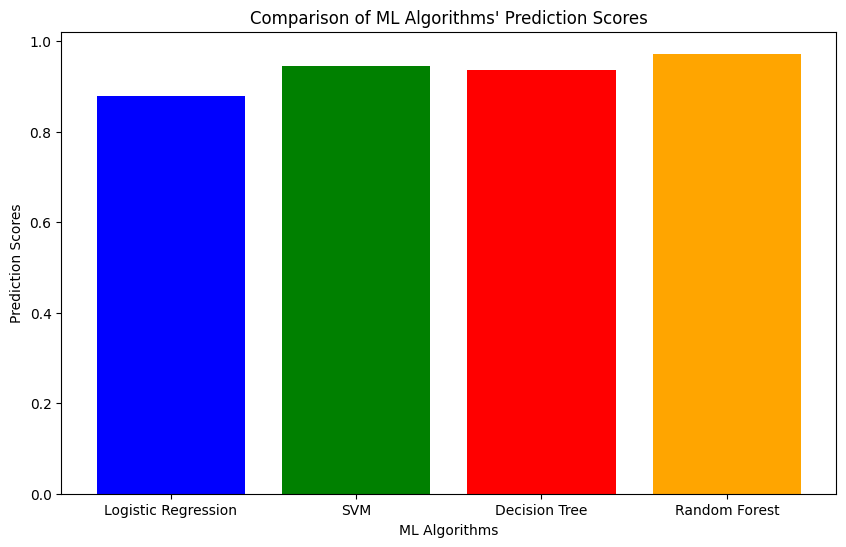

In [ ]:
# acurrency plot graph
import matplotlib.pyplot as plt

AlgorithmsName = [
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "Random Forest"
]

scores = [LRscore, SVMscore, DTCscore, RFCscore]

plt.figure(figsize=(10, 6))
plt.bar(AlgorithmsName, scores, color=['blue', 'green', 'red', 'orange'])
plt.xlabel('ML Algorithms')
plt.ylabel('Prediction Scores')
plt.title('Comparison of ML Algorithms\' Prediction Scores')
plt.show()

# Classification of all model

In [ ]:
for name, score in zip(AlgorithmsName, scores):
    print(f"{name}: {score:.4f}")

Logistic Regression: 0.8796
SVM: 0.9444
Decision Tree: 0.9352
Random Forest: 0.9722


In [ ]:
# Logistic regretion
from sklearn.metrics import classification_report

print(classification_report(y_test, ypred_LR))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        50
           1       0.88      0.90      0.89        58

    accuracy                           0.88       108
   macro avg       0.88      0.88      0.88       108
weighted avg       0.88      0.88      0.88       108



In [ ]:
#SVM
from sklearn.metrics import classification_report

print(classification_report(y_test, ypred_SVM))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.96      0.93      0.95        58

    accuracy                           0.94       108
   macro avg       0.94      0.95      0.94       108
weighted avg       0.95      0.94      0.94       108



In [ ]:
# Decision Tree
from sklearn.metrics import classification_report

print(classification_report(y_test, ypred_DTC))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           1       0.96      0.91      0.94        58

    accuracy                           0.94       108
   macro avg       0.93      0.94      0.94       108
weighted avg       0.94      0.94      0.94       108



In [ ]:
# Random Forest
from sklearn.metrics import classification_report

print(classification_report(y_test, ypred_RFC))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        50
           1       0.98      0.97      0.97        58

    accuracy                           0.97       108
   macro avg       0.97      0.97      0.97       108
weighted avg       0.97      0.97      0.97       108



In [ ]:
from joblib import dump

dump(RFC, "best_model.pkl")

['best_model.pkl']

In [ ]:
from joblib import load

model = load("best_model.pkl")

In [ ]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (428, 8)
x_test shape: (108, 8)


In [ ]:
print(len(y_pred))
print(len(y_test))

108
108


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[43  7]
 [ 6 52]]


# Testing

In [ ]:
y_pred = model.predict(x_test_sc)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = load("best_model.pkl")

y_pred = model.predict(x_test_sc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9722222222222222
Confusion Matrix:
 [[49  1]
 [ 2 56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        50
           1       0.98      0.97      0.97        58

    accuracy                           0.97       108
   macro avg       0.97      0.97      0.97       108
weighted avg       0.97      0.97      0.97       108



In [ ]:
import joblib

joblib.dump({
    "model": model,
    "scaler": scaler
}, "model.pkl")

['model.pkl']

In [ ]:
#! pip install streamlit

In [ ]:
!streamlit run app.py